In [ ]:
!pip install groq pandas matplotlib seaborn tabulate -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

Saving Superstore_Sales_Dataset.csv to Superstore_Sales_Dataset.csv


In [ ]:
df = pd.read_csv(file_name, encoding='latin1')

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region 

In [ ]:
def clean_superstore_data(df):

    print("\nStarting Data Cleaning...\n")

    # --------------------------------
    # Remove Duplicate Rows
    # --------------------------------
    initial_rows = len(df)

    df = df.drop_duplicates()

    print(f"Removed Duplicates: {initial_rows - len(df)}")

    # --------------------------------
    # Clean Column Names
    # --------------------------------
    df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

    # --------------------------------
    # Convert Dates
    # --------------------------------
    date_cols = ['order_date', 'ship_date']

    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # --------------------------------
    # Handle Missing Values
    # --------------------------------
    for col in df.columns:

        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')

        else:
            df[col] = df[col].fillna(df[col].median())

    # --------------------------------
    # Remove Negative Sales
    # --------------------------------
    if 'sales' in df.columns:
        df = df[df['sales'] >= 0]

    # --------------------------------
    # Remove Invalid Postal Codes
    # --------------------------------
    if 'postal_code' in df.columns:
        df['postal_code'] = pd.to_numeric(
            df['postal_code'],
            errors='coerce'
        )

    # --------------------------------
    # Create Extra Features
    # --------------------------------
    if 'order_date' in df.columns:

        df['year'] = df['order_date'].dt.year
        df['month'] = df['order_date'].dt.month
        df['month_name'] = df['order_date'].dt.month_name()

    print("\nData Cleaning Completed")

    return df

In [ ]:
df = clean_superstore_data(df)


Starting Data Cleaning...

Removed Duplicates: 0

Data Cleaning Completed


In [ ]:
def dataset_summary(df):

    print("\n================ DATASET SUMMARY ================\n")

    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    print("\nColumns:\n")
    print(df.columns.tolist())

    print("\nMissing Values:\n")
    print(df.isnull().sum())

    print("\nNumerical Statistics:\n")
    print(df.describe())

dataset_summary(df)



================ DATASET SUMMARY ================

Rows: 9800
Columns: 21

Columns:

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'year', 'month', 'month_name']

Missing Values:

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
year             0
month            0
month_name       0
dtype: int64

Numerical Statistics:

            row_id                     order_date  \
count  9800.000000                           9800   
mean   4900.500000  2017-04-12 12:19:14.938775552   
min       1.000000            2015-01-02 00:

In [ ]:
GROQ_API_KEY = "API_KEY_HERE"   

client = Groq(api_key=GROQ_API_KEY)

In [ ]:
def generate_context(df):

    context = f"""
    DATASET INFORMATION

    Columns:
    {list(df.columns)}

    Data Types:
    {df.dtypes}

    Sample Rows:
    {df.head(5).to_string()}

    Total Rows:
    {len(df)}

    IMPORTANT:
    - Use ONLY available columns.
    - Dataframe name is df.
    - Return ONLY raw executable Python code.
    Do NOT use markdown.
    Do NOT use ```python.
    - Do not hallucinate columns.
    - Do not create fake values.
    - Do not explain anything.
    """

    return context

In [ ]:
def ask_llm(question, context):

    prompt = f"""
    You are an expert Data Analyst.

    Dataset Context:
    {context}

    User Question:
    {question}

    TASK:
    1. Analyze the dataframe accurately.
    2. Use ONLY existing columns.
    3. Return valid executable Python code.
    4. Also provide a short explanation.
    5. Avoid hallucination.
    6. If question cannot be answered from data,
       say 'INSUFFICIENT DATA'.

    RESPONSE FORMAT:

    EXPLANATION:
    <short explanation>

    CODE:
    <python pandas code only>
    """

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content

In [ ]:
ALLOWED_KEYWORDS = [
    'df',
    'groupby',
    'mean',
    'sum',
    'max',
    'min',
    'count',
    'sort_values',
    'head',
    'plot',
    'value_counts',
    'corr',
    'describe',
    'nlargest',
    'nsmallest',
    'matplotlib',
    'plt'
]

def safe_execute(code):

    blocked_words = [
        'import os',
        'system(',
        'open(',
        '__',
        'exec(',
        'eval(',
        'subprocess',
        'rm -rf'
    ]

    for word in blocked_words:

        if word in code:
            raise Exception("Unsafe code detected!")

    local_vars = {
        'df': df,
        'pd': pd,
        'plt': plt,
        'sns': sns
    }

    exec(code, {}, local_vars)

In [ ]:
def run_query(question):

    print("\n================================================")
    print("USER QUESTION:")
    print(question)
    print("================================================")

    context = generate_context(df)

    response = ask_llm(question, context)

    print("\nLLM RESPONSE:\n")
    print(response)

    # ====================================================
    # EXTRACT EXPLANATION
    # ====================================================

    explanation = ""

    if "EXPLANATION:" in response:

        explanation = response.split("CODE:")[0]

        print("\n================ XAI EXPLANATION ================\n")
        print(explanation)

    # ====================================================
    # EXTRACT CODE
    # ====================================================

    if "CODE:" in response:

        code = response.split("CODE:")[1].strip()

    else:
        print("No executable code generated.")
        return

    # ====================================================
    # REMOVE MARKDOWN BACKTICKS
    # ====================================================

    code = code.replace("```python", "")
    code = code.replace("```", "")
    code = code.strip()

    print("\n================ GENERATED CODE ================\n")
    print(code)

    # ====================================================
    # SAFE EXECUTION
    # ====================================================

    try:

      print("\n================ RESULT ================\n")

      local_scope = {
          'df': df,
          'pd': pd,
          'plt': plt,
          'sns': sns,
          'np': np
      }

      # --------------------------------------------
      # CHECK IF CODE IS SIMPLE EXPRESSION
      # --------------------------------------------

      if "\n" not in code and "plt." not in code:

          result = eval(code, {}, local_scope)

          print(result)

      else:

          exec(code, {}, local_scope)

    except Exception as e:

      print("\nExecution Error:")
      print(e)


USER QUESTION:
Which category has highest total sales?

LLM RESPONSE:

EXPLANATION:
To find the category with the highest total sales, we need to group the data by the 'category' column and calculate the sum of 'sales' for each group. Then, we can sort the results in descending order and get the category with the highest total sales.

CODE:
df.groupby('category')['sales'].sum().sort_values(ascending=False).head(1)

================ XAI EXPLANATION ================

EXPLANATION:
To find the category with the highest total sales, we need to group the data by the 'category' column and calculate the sum of 'sales' for each group. Then, we can sort the results in descending order and get the category with the highest total sales.



================ GENERATED CODE ================

df.groupby('category')['sales'].sum().sort_values(ascending=False).head(1)

================ RESULT ================

category
Technology    827455.873
Name: sales, dtype: float64

USER QUESTION:
Show top 10 pro

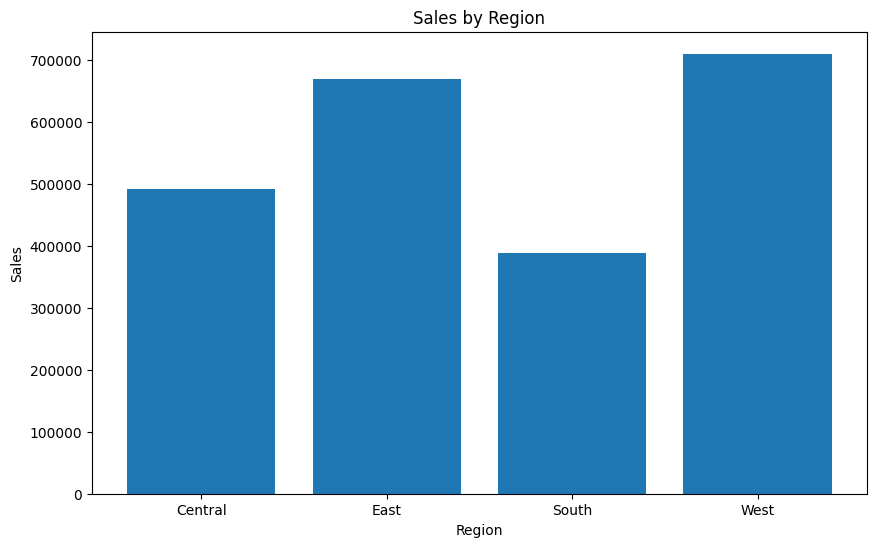

In [ ]:
run_query("Which category has highest total sales?")

run_query("Show top 10 products by sales")

run_query("Plot sales by region")

In [ ]:

while True:

    question = input("\nAsk Your Question (type exit to stop): ")

    if question.lower() == 'exit':
        print("Session Ended")
        break

    run_query(question)


Ask Your Question (type exit to stop): exit
Session Ended
